In [21]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('collegiate_athlete_injury_dataset.csv')

print("Dimensions du dataset :", df.shape)
print("\nAperçu des données :")
print(df.head())
print("\nNom des colonnes :")
print(df.columns.tolist())
print("\nTypes de variables :")
print(df.dtypes)
print("\nValeurs manquantes :")
print(df.isnull().sum())

Dimensions du dataset : (200, 17)

Aperçu des données :
  Athlete_ID  Age  Gender  Height_cm  Weight_kg Position  Training_Intensity  \
0       A001   24  Female        195         99   Center                   2   
1       A002   21    Male        192         65  Forward                   8   
2       A003   22    Male        163         83    Guard                   8   
3       A004   24  Female        192         90    Guard                   1   
4       A005   20  Female        173         79   Center                   3   

   Training_Hours_Per_Week  Recovery_Days_Per_Week  Match_Count_Per_Week  \
0                       13                       2                     3   
1                       14                       1                     3   
2                        8                       2                     1   
3                       13                       1                     1   
4                        9                       1                     2   

   Res

# Contexte et problématique

Moi-même victime d'une rupture du ligament croisé antérieur, j'ai voulu comprendre pourquoi les femmes sportives y sont 
statistiquement plus exposées. Ce notebook explore les facteurs de risque de blessure chez des athlètes universitaires à partir 
d'un dataset de 200 observations et 17 variables.

**Problématique : quels facteurs sont statistiquement associés au risque de blessure chez les femmes sportives ?**

In [22]:
# Statistiques descriptives générales
print("=== STATISTIQUES GÉNÉRALES ===")
print(df.describe().round(2))

# Répartition hommes/femmes
print("\n=== RÉPARTITION PAR GENRE ===")
print(df['Gender'].value_counts())

# Taux de blessure par genre
print("\n=== TAUX DE BLESSURE PAR GENRE ===")
print(df.groupby('Gender')['Injury_Indicator'].mean().round(3))

# Score de risque LCA par genre
print("\n=== SCORE DE RISQUE LCA PAR GENRE ===")
print(df.groupby('Gender')['ACL_Risk_Score'].mean().round(2))

=== STATISTIQUES GÉNÉRALES ===
          Age  Height_cm  Weight_kg  Training_Intensity  \
count  200.00     200.00     200.00              200.00   
mean    21.17     180.80      77.47                5.11   
std      2.00      11.53      12.44                2.50   
min     18.00     160.00      55.00                1.00   
25%     19.00     171.00      67.00                3.00   
50%     21.00     182.50      77.50                5.00   
75%     23.00     191.00      89.00                7.00   
max     24.00     199.00      99.00                9.00   

       Training_Hours_Per_Week  Recovery_Days_Per_Week  Match_Count_Per_Week  \
count                   200.00                  200.00                200.00   
mean                     11.32                    1.98                  2.38   
std                       4.44                    0.81                  1.15   
min                       5.00                    1.00                  1.00   
25%                       7.00       

## Premières observations

107 femmes et 93 hommes dans le dataset.
Les femmes ont un taux de blessure légèrement plus élevé (7.5% vs 6.5%).
Mais le score de risque LCA est paradoxalement plus élevé chez les hommes.
Ça m'amène à creuser : quels autres facteurs expliquent réellement le risque de blessure ?

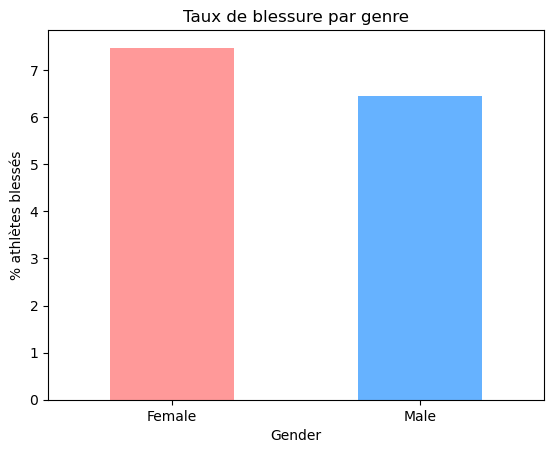

In [23]:
# d'abord juste le taux de blessure par genre
# pour voir si la différence est visible
injury_rate = df.groupby('Gender')['Injury_Indicator'].mean() * 100
injury_rate.plot(kind='bar', color=['#FF9999', '#66B2FF'])
plt.title('Taux de blessure par genre')
plt.ylabel('% athlètes blessés')
plt.xticks(rotation=0)
plt.show()

Le graphique confirme que les femmes ont un taux de blessure légèrement supérieur aux hommes (7.5% vs 6.5%). 
L'écart est faible mais cohérent avec la littérature médicale sur la vulnérabilité des femmes aux blessures ligamentaires.

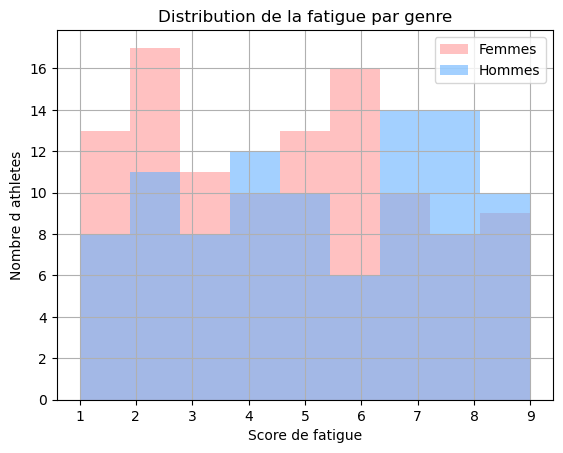

In [24]:
# la fatigue est elle différente selon le genre ?
# je veux voir si les femmes accumulent plus de fatigue
df[df['Gender']=='Female']['Fatigue_Score'].hist(
    alpha=0.6, color='#FF9999', label='Femmes', bins=9)
df[df['Gender']=='Male']['Fatigue_Score'].hist(
    alpha=0.6, color='#66B2FF', label='Hommes', bins=9)
plt.title('Distribution de la fatigue par genre')
plt.xlabel('Score de fatigue')
plt.ylabel('Nombre d athletes')
plt.legend()
plt.show()

Contrairement à ce que j'attendais, les hommes semblent accumuler des scores de fatigue plus élevés que les femmes.
Pourtant leur taux de blessure est plus faible.
La fatigue seule ne suffit donc pas à expliquer le risque de blessure d'autres facteurs entrent en jeu.

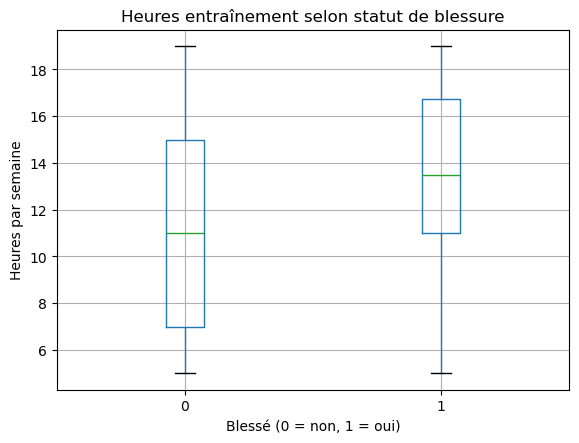

In [25]:
# est ce que les athlètes blessés s'entraînent plus ?
df.boxplot(column='Training_Hours_Per_Week', by='Injury_Indicator')
plt.title('Heures entraînement selon statut de blessure')
plt.suptitle('')
plt.xlabel('Blessé (0 = non, 1 = oui)')
plt.ylabel('Heures par semaine')
plt.show()

Les athlètes blessés ont une médiane d'heures d'entraînement plus élevée que les non-blessés.
Ça suggère que la surcharge d'entraînement est un facteur de risque important et ceux indépendamment du genre.
Ce résultat rejoint les études médicales sur le rôle de la charge de travail dans les blessures ligamentaires.

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

# je convertis le genre en variable numérique
# Female = 1, Male = 0
df['Gender_num'] = (df['Gender'] == 'Female').astype(int)

# je choisis mes variables explicatives
X = df[['Gender_num', 'Age', 'Training_Hours_Per_Week', 
        'Fatigue_Score', 'Recovery_Days_Per_Week',
        'Training_Intensity', 'ACL_Risk_Score']]
y = df['Injury_Indicator']

# je standardise pour que les variables soient comparables
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# j'estime le modèle
model = LogisticRegression()
model.fit(X_scaled, y)

# je regarde quels facteurs pèsent le plus
coefficients = pd.DataFrame({
    'Variable': X.columns,
    'Coefficient': model.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coefficients)

                  Variable  Coefficient
6           ACL_Risk_Score     2.681061
3            Fatigue_Score     0.525443
0               Gender_num     0.264168
2  Training_Hours_Per_Week     0.123232
5       Training_Intensity     0.014894
1                      Age    -0.080451
4   Recovery_Days_Per_Week    -0.538884


## Limite identifiée et ajustement de l'analyse

En regardant les résultats de la régression, je réalise que le score ACL_Risk_Score domine complètement le modèle mais on ne connaît pas ses composantes exactes.

Par ailleurs on a vu plus haut que ce score est paradoxalement plus élevé chez les hommes alors qu'ils se blessent moins.

Je vais donc de faire deux choses :
1. Comparer ce score par genre pour comprendre l'incohérence
2. Puis refaire la régression sans ce score pour isoler les facteurs comportementaux et physiques purs

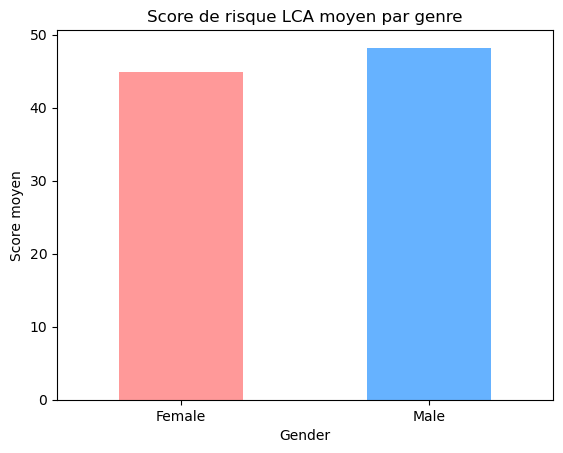

Gender
Female    44.943925
Male      48.225806
Name: ACL_Risk_Score, dtype: float64


In [27]:
# le score LCA est plus élevé chez qui ?
# paradoxe : les hommes ont un score plus élevé mais se blessent moins
acl_by_gender = df.groupby('Gender')['ACL_Risk_Score'].mean()
acl_by_gender.plot(kind='bar', color=['#FF9999', '#66B2FF'])
plt.title('Score de risque LCA moyen par genre')
plt.ylabel('Score moyen')
plt.xticks(rotation=0)
plt.show()
print(acl_by_gender)

#### Un paradoxe qui remet en question mon modèle

Comme constaté plus haut, les hommes ont un score de risque LCA plus élevé que les femmes (48.2 vs 44.9) alors qu'ils se blessent moins (6.5% vs 7.5%).

Ce paradoxe m'amène à questionner ce score : que mesure-t-il exactement ? Si un score de risque LCA plus élevé ne prédit pas 
plus de blessures réelles, son utilisation dans mon modèle de régression est discutable.

Je vais refaire l'analyse sans ce score pour isoler les facteurs que je comprends vraiment : heures d'entraînement, fatigue, récupération, genre.


In [28]:
# régression sans le score LCA
# pour isoler les vrais facteurs comportementaux
X2 = df[['Gender_num', 'Age', 'Training_Hours_Per_Week',
         'Fatigue_Score', 'Recovery_Days_Per_Week',
         'Training_Intensity']]

X2_scaled = scaler.fit_transform(X2)
model2 = LogisticRegression()
model2.fit(X2_scaled, y)

coefficients2 = pd.DataFrame({
    'Variable': X2.columns,
    'Coefficient': model2.coef_[0]
}).sort_values('Coefficient', ascending=False)

print(coefficients2)

                  Variable  Coefficient
3            Fatigue_Score     1.651929
2  Training_Hours_Per_Week     0.711931
5       Training_Intensity     0.469044
0               Gender_num     0.301382
1                      Age    -0.161236
4   Recovery_Days_Per_Week    -1.315351


### Résultats du modèle ajusté et conclusion

Sans le score ACL, les résultats sont plus lisibles et directement actionnables.

La fatigue est le premier facteur de risque, devant la charge et l'intensité d'entraînement.

Le genre féminin reste un facteur de risque indépendant même en contrôlant tous les autres facteurs, ce qui confirme qu'il existe des facteurs biologiques propres aux femmes qui les rendent plus vulnérables aux blessures ligamentaires.

Mais le résultat le plus important est ailleurs : 
la récupération est le facteur protecteur le plus puissant du modèle. C'est un levier d'action concret et donc augmenter les jours de récupération réduit significativement le risque de blessure, chez les femmes comme chez les hommes.

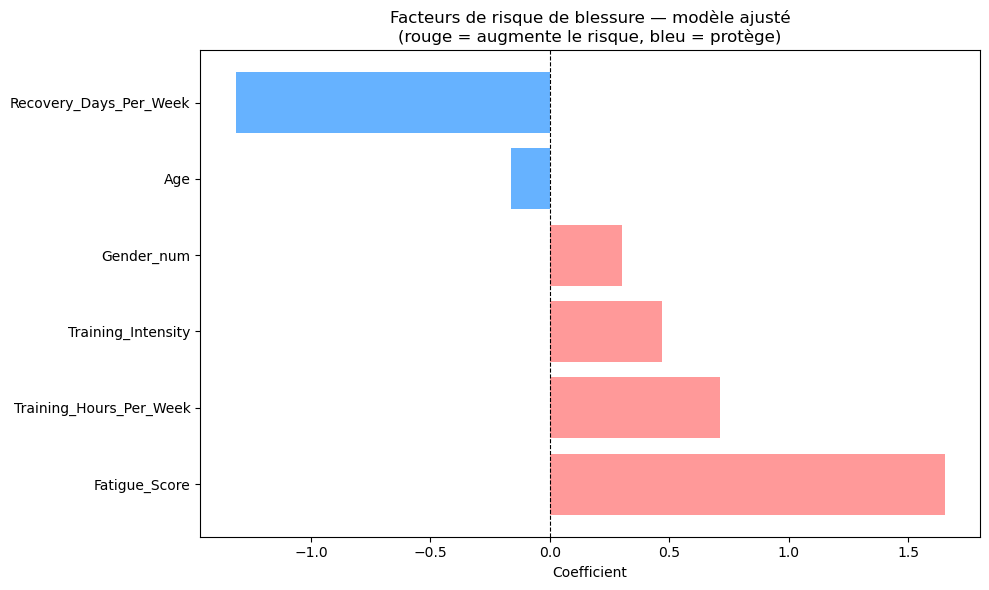

In [29]:
# visualisation des facteurs du modèle ajusté
# rouge = augmente le risque, bleu = protège
colors = ['#FF9999' if c > 0 else '#66B2FF' 
          for c in coefficients2['Coefficient']]

plt.figure(figsize=(10, 6))
plt.barh(coefficients2['Variable'],
         coefficients2['Coefficient'],
         color=colors)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)
plt.title('Facteurs de risque de blessure — modèle ajusté\n(rouge = augmente le risque, bleu = protège)')
plt.xlabel('Coefficient')
plt.tight_layout()
plt.savefig('facteurs_risque_ajuste.png', dpi=150)
plt.show()

#### Ce que ce graphique résume

En rouge, les facteurs qui augmentent le risque de blessure : la fatigue en tête, suivie des heures d'entraînement, de l'intensité, et du genre féminin.

En bleu, les facteurs protecteurs : la récupération est de loin le plus puissant, devant l'âge qui joue un rôle plutôt mineur.

On peut constater que la fatigue est plus élevée chez les hommes dans ce dataset, pourtant les femmes se blessent davantage.
Cela suggère qu'à niveau de fatigue comparable, les femmes restent plus exposées au risque de blessure. Ce que confirme le coefficient positif du genre dans le modèle.

Les facteurs biologiques propres aux femmes (hormonaux, anatomiques, biomécaniques) qui pourraient expliquer cette vulnérabilité supplémentaire ne sont pas capturés par ce dataset et constituent une limite de cette analyse.

*C'est précisément ce type de question comment modéliser des facteurs de risque complexes sur des populations spécifiques que je veux apprendre à traiter rigoureusement.*

## Conclusion générale

Cette analyse exploratoire sur 200 athlètes universitaires m'a permis d'identifier trois résultats principaux :

1. La surcharge d'entraînement et la fatigue augmentent le risque de blessure pour tous les athlètes

2. La récupération est le facteur protecteur le plus puissant : c'est le levier d'action le plus concret pour les staffs sportifs

3. Le genre féminin reste un facteur de risque indépendant même en contrôlant tous les autres facteurs comportementaux ce qui suggère l'existence de facteurs biologiques propres aux femmes qui justifient des protocoles de prévention spécifiques

Limites : dataset de 200 observations, variables comportementales uniquement, des données biomécaniques et hormonales 
permettraient d'affiner ces résultats.


## Régression logistique économétrique

Pour aller plus loin que le modèle précédent, je refais la régression avec statsmodels qui donne les p-values 
et les intervalles de confiance pour voir quelles variables sont vraiment statistiquement significatives et pas juste corrélées par pur hasard.

In [34]:
import statsmodels.api as sm

# j'ajoute une constante au modèle
X2_sm = sm.add_constant(X2)

# j'estime le modèle logistique
model_sm = sm.Logit(y, X2_sm)
result = model_sm.fit()

# puis j'affiche le tableau complet
print(result.summary())

Optimization terminated successfully.
         Current function value: 0.134932
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:       Injury_Indicator   No. Observations:                  200
Model:                          Logit   Df Residuals:                      193
Method:                           MLE   Df Model:                            6
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.4680
Time:                        17:14:31   Log-Likelihood:                -26.986
converged:                       True   LL-Null:                       -50.728
Covariance Type:            nonrobust   LLR p-value:                 1.499e-08
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -7.5423      4.435     -1.701      0.089     -16.234  

## Lecture des résultats économétriques

Trois variables sont statistiquement significatives au seuil de 5% :

La fatigue (p=0.001) et la surcharge d'entraînement (p=0.019) augmentent significativement le risque de blessure.

La récupération (p=0.001) est le facteur protecteur le plus robuste du modèle.

Le genre féminin va dans la direction attendue (coefficient positif) mais n'est pas statistiquement 
significatif sur ce dataset de 200 observations. 
Ce résultat ne contredit pas la littérature médicale, il suggère qu'un échantillon plus large serait nécessaire 
pour isoler l'effet pur du genre avec suffisamment de puissance statistique.

Le modèle présente un Pseudo R² de 0.47. Avec seulement 6 variables comportementales, mon modèle explique près de la moitié du risque de blessure. Les 53% restants sont probablement liés à des facteurs biologiques et biomécaniques absents du dataset, ce qui ouvre effectivement des pistes pour une analyse plus complète.

## Analyse spécifique sur les femmes sportives

Puisque mon hypothèse de départ porte sur la vulnérabilité spécifique des femmes, je refais la régression uniquement sur les athlètes féminines pour identifier quels facteurs sont les plus déterminants dans cette sous-population.

In [35]:
# je filtre uniquement les femmes
df_women = df[df['Gender'] == 'Female'].copy()

print("Nombre d'athlètes féminines :", len(df_women))
print("Nombre de blessées :", df_women['Injury_Indicator'].sum())
print("Taux de blessure :", 
      round(df_women['Injury_Indicator'].mean() * 100, 1), "%")

# meme modele mais sur les femmes uniquement
X_women = df_women[['Age', 'Training_Hours_Per_Week',
                     'Fatigue_Score', 'Recovery_Days_Per_Week',
                     'Training_Intensity']]
y_women = df_women['Injury_Indicator']

X_women_sm = sm.add_constant(X_women)
model_women = sm.Logit(y_women, X_women_sm)
result_women = model_women.fit()

print(result_women.summary())

Nombre d'athlètes féminines : 107
Nombre de blessées : 8
Taux de blessure : 7.5 %
Optimization terminated successfully.
         Current function value: 0.116251
         Iterations 10
                           Logit Regression Results                           
Dep. Variable:       Injury_Indicator   No. Observations:                  107
Model:                          Logit   Df Residuals:                      101
Method:                           MLE   Df Model:                            5
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.5626
Time:                        17:14:36   Log-Likelihood:                -12.439
converged:                       True   LL-Null:                       -28.440
Covariance Type:            nonrobust   LLR p-value:                 5.934e-06
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------

## Résultats sur les femmes uniquement

Sur les 107 athlètes féminines, 8 se sont blessées (7.5%).

Le modèle spécifique aux femmes est plus performant que le modèle général (Pseudo R²=0.56 vs 0.47). Ce qui confirme que les déterminants du risque de blessure sont différents selon le genre.

Trois facteurs sont statistiquement significatifs chez les femmes :

La récupération insuffisante est le facteur le plus critique (p=0.010, coef=-3.20) 
Son effet protecteur est deux fois plus imprtant chez les femmes que dans la population générale.

La fatigue (p=0.019) et la surcharge d'entraînement (p=0.036) augmentent significativement le risque.

Ce que ça veut dire : chez les femmes sportives, augmenter les jours de récupération serait l'intervention la plus efficace pour réduire le risque de blessure, bien plus que de réduire l'intensité ou les heures d'entraînement.

Limite : seulement 8 blessures dans l'échantillon féminin, le message de quasi-séparation indique que le modèle 
est à la limite de ce qu'on peut estimer sur ce volume de données. Ces résultats sont indicatifs et nécessitent confirmation sur un dataset plus large.

In [33]:
# même modèle sur les hommes pour comparer
df_men = df[df['Gender'] == 'Male'].copy()

print("Nombre d'athlètes masculins :", len(df_men))
print("Nombre de blessés :", df_men['Injury_Indicator'].sum())
print("Taux de blessure :", 
      round(df_men['Injury_Indicator'].mean() * 100, 1), "%")

X_men = df_men[['Age', 'Training_Hours_Per_Week',
                'Fatigue_Score', 'Recovery_Days_Per_Week',
                'Training_Intensity']]
y_men = df_men['Injury_Indicator']

X_men_sm = sm.add_constant(X_men)
model_men = sm.Logit(y_men, X_men_sm)
result_men = model_men.fit()

print(result_men.summary())

Nombre d'athlètes masculins : 93
Nombre de blessés : 6
Taux de blessure : 6.5 %
Optimization terminated successfully.
         Current function value: 0.145532
         Iterations 9
                           Logit Regression Results                           
Dep. Variable:       Injury_Indicator   No. Observations:                   93
Model:                          Logit   Df Residuals:                       87
Method:                           MLE   Df Model:                            5
Date:                Tue, 17 Mar 2026   Pseudo R-squ.:                  0.3916
Time:                        16:28:42   Log-Likelihood:                -13.534
converged:                       True   LL-Null:                       -22.247
Covariance Type:            nonrobust   LLR p-value:                  0.003760
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
co

## Comparaison hommes / femmes — résultats

La comparaison des deux modèles révèle des différences importantes dans les déterminants du risque de blessure 
selon le genre.

En faisant tourner le même modèle sur les hommes, les différences sont frappantes.

La fatigue ressort comme significative dans les deux groupes, c'est le seul facteur de risque commun.

Mais la récupération raconte quelque chose d'intéressant : elle est fortement significative chez les femmes (p=0.010) avec un coefficient de -3.21, alors que chez les hommes elle va dans la même direction mais n'est pas significative (p=0.069, coef=-1.57). Autrement dit,la récupération protège les deux, mais elle protège beaucoup plus les femmes.

Même chose pour les heures d'entraînement : significatives chez les femmes (p=0.036), pas chez les hommes (p=0.235). 
À charge de travail égale, les femmes semblent plus exposées.

Le Pseudo R² confirme ça, le modèle explique mieux le risque féminin (0.56) que masculin (0.39). 
Les facteurs comportementaux que j'ai mesurés sont plus déterminants chez les femmes.

Ce que ça implique concrètement : un protocole de prévention identique pour les hommes et les femmes n'a pas vraiment 
de sens, la gestion de la récupération et de la charge mérite une approche spécifique pour les femmes sportives.

### Question ouverte : la récupération est le levier le plus efficace mais elle est souvent contrainte par les calendriers imposés par les exigences du haut-niveau.

La vraie question de recherche devient alors : comment optimiser la prévention des blessures sous contrainte de calendrier ?

## Mise en perspective avec la littérature scientifique

Trois études récentes éclairent et nuancent mes résultats :

### Ce que confirme la littérature

Une étude UEFA sur 596 joueuses professionnelles européennes sur 4 saisons (2018-2022) confirme que la blessure ACL 
est la plus coûteuse du football féminin : 292 jours d'absence en médiane, soit presque une saison entière.

L'incidence des blessures est 4 fois plus élevée en match qu'à l'entraînement, ce qui rejoint mon résultat sur le rôle de la charge dans le risque de blessure. 

*Ces chiffres réels sur des professionnelles européennes donnent une dimension économique concrète à mon analyse :
une blessure ACL coûte en moyenne une saison de compétition. La prévention n'est pas seulement une question médicale, c'est un enjeu économique majeur pour les clubs.* ***Limite : mon dataset porte sur des athlètes universitaires américains. Les résultats ne sont pas directement comparables aux professionnelles européennes. Mais la convergence des facteurs de risque identifiés renforce la robustesse de mon analyse.***

Une méta-analyse sur 11 773 joueuses montre que des programmes de prévention multicomposants réduisent les blessures ACL 
de 45%. Ce chiffre donne une dimension économique concrète à mon analyse : si la récupération est le facteur protecteur 
le plus puissant dans mon modèle, elle s'inscrit dans une logique de prévention dont l'efficacité est prouvée à grande échelle.


### Ce que la littérature révèle que mon modèle ne capture pas

Une revue sur l'effet du cycle menstruel montre que les variations hormonales affectent la laxité du genou et la fonction neuromusculaire mais les preuves restent peu concluantes sur quelle phase expose le plus au risque ACL.

C'est exactement la limite que j'avais identifiée plus haut, mon dataset ne contient aucune variable biologique ou hormonale. Le coefficient positif du genre dans mon modèle capte probablement une partie de ces facteurs sans pouvoir veritablement les isoler.

### Implication pour la recherche

Ces trois études convergent vers une conclusion commune, la prévention des blessures ACL chez les femmes est un problème d'optimisation économique autant que médical. 
Quantifier l'impact d'un programme de prévention, modéliser son coût-bénéfice pour un club professionnel, intégrer des variables biologiques dans un modèle de risque c'est précisément ce type de question que les outils économétriques permettent de traiter.


**Sources**

1. Larruskain J. et al. *UEFA Women's Elite Club Injury Study*, 
British Journal of Sports Medicine, 2022.

2. Herzberg SD. et al. *Effects of the menstrual cycle phase 
on ACL neuromuscular and biomechanical injury risk surrogates*, 
International Journal of Sports Physical Therapy, 2017.

3. Nilstad A. et al. *Risk factors for lower extremity injuries 
in elite female soccer players*, 
American Journal of Sports Medicine, 2014.

4. Crossley KM. et al. *Making football safer for women*, 
British Journal of Sports Medicine, 2020.